In [2]:
import sqlite3

# Connect to (or create) the database file
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [3]:
# Create the 'sales' table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS sales (
        product TEXT,
        quantity INTEGER,
        price REAL
    )
""")

In [4]:
# Insert sample data (optional)
cursor.execute("INSERT INTO sales VALUES ('Apple', 10, 1.99)")
cursor.execute("INSERT INTO sales VALUES ('Banana', 5, 0.99)")
cursor.execute("INSERT INTO sales VALUES ('Apple', 3, 1.99)")

In [5]:
# Commit changes and close
conn.commit()
conn.close()

In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect("sales_data.db")

In [7]:
# Query 1: Total quantity and revenue per product
query = """
    SELECT 
        product,
        SUM(quantity) AS total_quantity,
        SUM(quantity * price) AS revenue
    FROM sales
    GROUP BY product
"""

In [8]:
# Load data into a pandas DataFrame
df = pd.read_sql_query(query, conn)

In [9]:
# Print results
print("Sales Summary:")
print(df)

Sales Summary:
  product  total_quantity  revenue
0   Apple              13    25.87
1  Banana               5     4.95


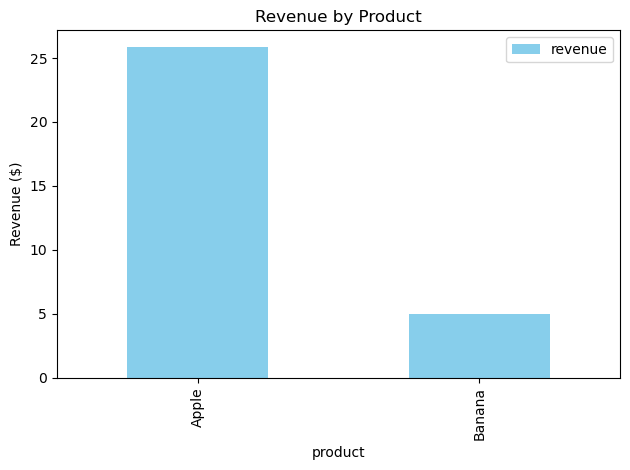

In [10]:
# Plot a bar chart (revenue by product)
df.plot(kind='bar', x='product', y='revenue', color='skyblue')
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Save the chart
plt.show()

In [11]:
# Close the connection
conn.close()